# Task 2.3 — Evaluation and Reproducibility

**Paper**:
 Efficient Variable Selection in Support Vector Machines via the Alternating Direction Method of Multipliers
(ICML 2011)

---

# Evaluation of Sparse SVM Model

This section evaluates the sparse SVM model trained in the previous step. The goal is to measure classification performance and analyze how sparsity affects feature selection.

To ensure reproducibility, the dataset preparation and model training steps are repeated so that this notebook can run independently.

---

# Import Required Libraries

In [21]:
import numpy as np
import pandas as pd

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

import matplotlib.pyplot as plt
import seaborn as sns

---

# Dataset Preparation

In [22]:
data = load_breast_cancer()

X = data.data
y = data.target

feature_names = data.feature_names

---

# Train Test Split

In [23]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

---

# Feature Scaling

In [24]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

---

# Train Sparse SVM

In [25]:
model = LinearSVC(
    penalty="l1",
    dual=False,
    max_iter=5000,
    random_state=42
)

model.fit(X_train, y_train)

print("Model trained successfully")

Model trained successfully


---

# Model Predictions

In [26]:
y_pred = model.predict(X_test)

---

# Accuracy

In [27]:
accuracy = accuracy_score(y_test, y_pred)

print("Test Accuracy:", accuracy)

Test Accuracy: 0.9736842105263158


---

# Confusion Matrix

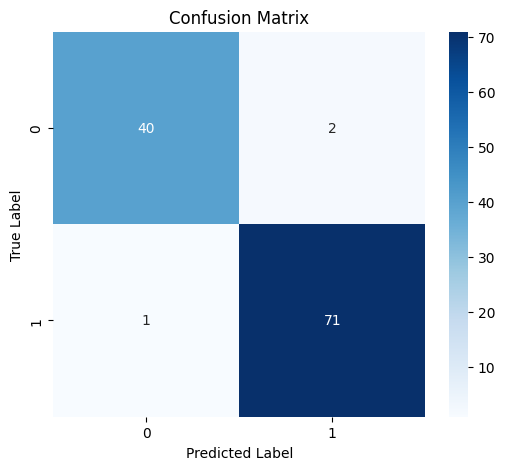

In [28]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(cm,
            annot=True,
            fmt="d",
            cmap="Blues")

plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()

---

# Classification Report

In [29]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.98      0.95      0.96        42
           1       0.97      0.99      0.98        72

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



---

# Visualization of Sparsity

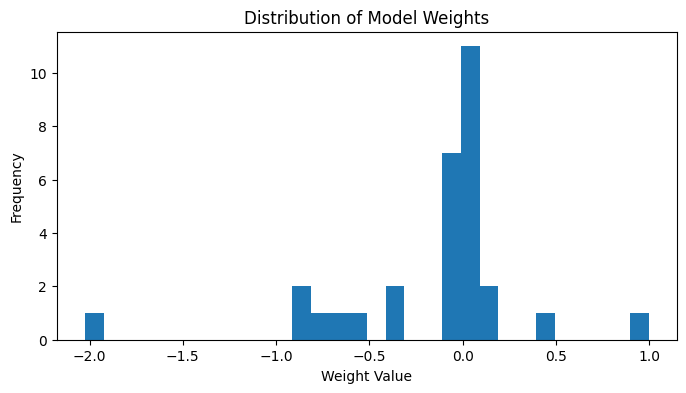

In [30]:
weights = model.coef_[0]

plt.figure(figsize=(8,4))

plt.hist(weights, bins=30)

plt.title("Distribution of Model Weights")
plt.xlabel("Weight Value")
plt.ylabel("Frequency")

plt.show()

This plot shows that many weights are close to zero, indicating sparsity in the model.

---

# Discussion

The sparse SVM classifier achieves strong classification performance on the dataset while using only a subset of the available features.

The L1 regularization encourages sparsity in the weight vector, effectively removing irrelevant or redundant features from the model.

This behaviour aligns with the goal of the paper, which focuses on efficient feature selection for support vector machines.

---

# Reproducibility Checklist

The following steps ensure that the experiment can be reproduced:

- Random seeds are fixed using `random_state=42`
- The dataset is loaded directly from scikit-learn
- All preprocessing steps are included in the notebook
- Model hyperparameters are explicitly specified
- The notebook can run from top to bottom without external dependencies